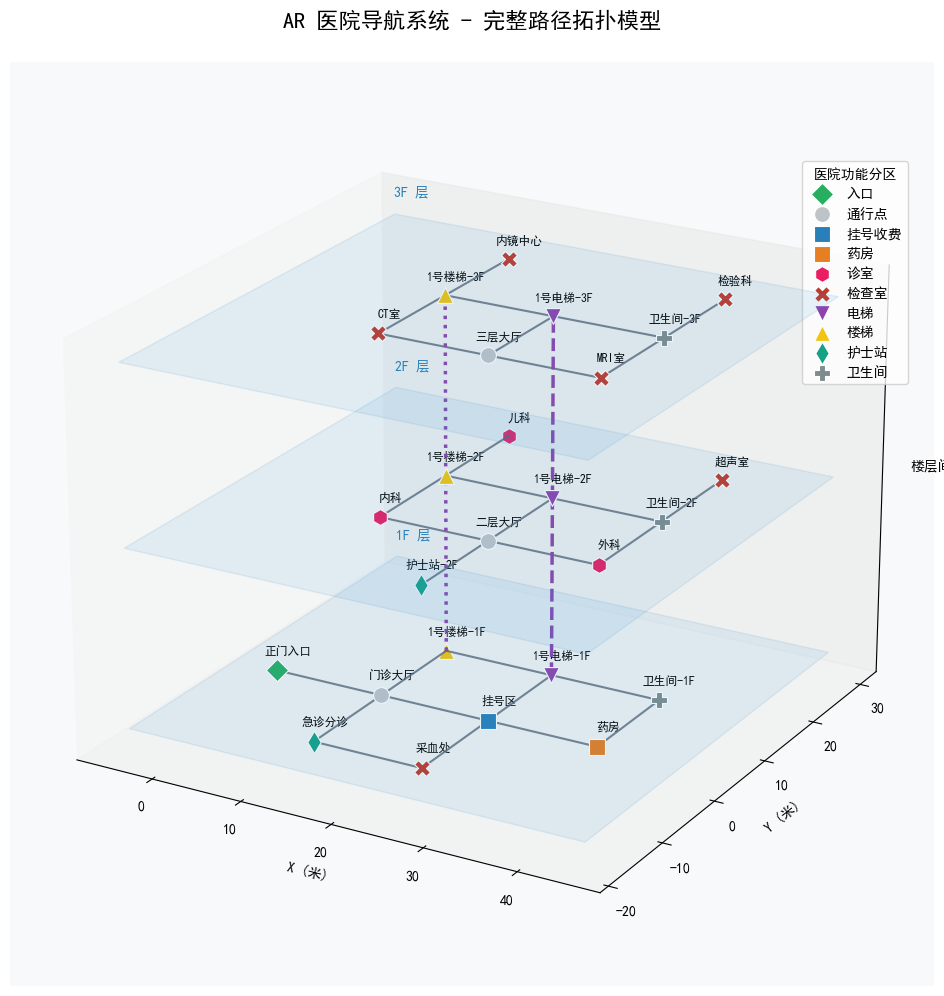

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib

# --- 1. 环境配置 ---
matplotlib.rc('font', family='SimHei') 
matplotlib.rcParams['axes.unicode_minus'] = False 

# --- 2. 节点与边数据定义 ---
# 节点类型映射与样式
type_map_zh = {
    'NORMAL': '通行点', 'ENTRANCE': '入口', 'REGISTRATION': '挂号收费',
    'PHARMACY': '药房', 'ELEVATOR': '电梯', 'STAIRS': '楼梯',
    'RESTROOM': '卫生间', 'CLINIC': '诊室', 'NURSE_STATION': '护士站',
    'EXAMINATION': '检查室'
}
type_styles = {
    'NORMAL': ('#bdc3c7', 'o'), 'ENTRANCE': ('#27ae60', 'D'),
    'REGISTRATION': ('#2980b9', 's'), 'PHARMACY': ('#e67e22', 's'),
    'ELEVATOR': ('#8e44ad', 'v'), 'STAIRS': ('#f1c40f', '^'),
    'RESTROOM': ('#7f8c8d', 'P'), 'CLINIC': ('#e91e63', 'h'),
    'NURSE_STATION': ('#16a085', 'd'), 'EXAMINATION': ('#c0392b', 'X')
}

# 完整节点数据 (ID, 名称, 楼层, X, Y, 类型)
full_nodes = [
    (1, '正门入口', 1, 0, 0, 'ENTRANCE'), (2, '门诊大厅', 1, 12, 0, 'NORMAL'),
    (3, '挂号区', 1, 24, 0, 'REGISTRATION'), (4, '药房', 1, 36, 0, 'PHARMACY'),
    (5, '1号电梯-1F', 1, 24, 12, 'ELEVATOR'), (6, '1号楼梯-1F', 1, 12, 12, 'STAIRS'),
    (7, '卫生间-1F', 1, 36, 12, 'RESTROOM'), (8, '急诊分诊', 1, 12, -12, 'NURSE_STATION'),
    (9, '采血处', 1, 24, -12, 'EXAMINATION'),
    (10, '二层大厅', 2, 24, 0, 'NORMAL'), (11, '内科', 2, 12, 0, 'CLINIC'),
    (12, '外科', 2, 36, 0, 'CLINIC'), (13, '儿科', 2, 12, 24, 'CLINIC'),
    (14, '超声室', 2, 36, 24, 'EXAMINATION'), (15, '1号电梯-2F', 2, 24, 12, 'ELEVATOR'),
    (16, '1号楼梯-2F', 2, 12, 12, 'STAIRS'), (17, '卫生间-2F', 2, 36, 12, 'RESTROOM'),
    (18, '护士站-2F', 2, 24, -12, 'NURSE_STATION'),
    (19, '三层大厅', 3, 24, 0, 'NORMAL'), (20, 'CT室', 3, 12, 0, 'EXAMINATION'),
    (21, 'MRI室', 3, 36, 0, 'EXAMINATION'), (22, '内镜中心', 3, 12, 24, 'EXAMINATION'),
    (23, '检验科', 3, 36, 24, 'EXAMINATION'), (24, '1号电梯-3F', 3, 24, 12, 'ELEVATOR'),
    (25, '1号楼梯-3F', 3, 12, 12, 'STAIRS'), (26, '卫生间-3F', 3, 36, 12, 'RESTROOM')
]

# 边数据 (模拟 hospital_edges 的拓扑结构)
raw_edges = [
    # 1楼路径
    (1,2), (2,3), (3,4), (3,5), (2,6), (4,7), (2,8), (3,9), (6,5), (5,7), (8,9),
    # 2楼路径
    (11,10), (10,12), (10,15), (11,16), (12,17), (16,15), (15,17), (16,13), (17,14), (10,18),
    # 3楼路径
    (20,19), (19,21), (19,24), (20,25), (21,26), (25,24), (24,26), (25,22), (26,23),
    # 垂直路径 (跨楼层)
    (5,15), (15,24), (6,16), (16,25)
]

# --- 3. 绘图函数 ---
def plot_hospital_with_paths():
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#f8f9fa') 

    floor_h = {1: 0, 2: 10, 3: 20} # 保持楼层间距
    node_dict = {n[0]: n for n in full_nodes}

    # A. 绘制地板
    x_range, y_range = [-5, 45], [-18, 30]
    for f, z in floor_h.items():
        verts = [[(x_range[0], y_range[0], z), (x_range[1], y_range[0], z), 
                  (x_range[1], y_range[1], z), (x_range[0], y_range[1], z)]]
        ax.add_collection3d(Poly3DCollection(verts, alpha=0.1, facecolor='#3498db', edgecolor='#2980b9'))
        ax.text(x_range[0], y_range[1], z + 1, f'{f}F 层', color='#2980b9', fontweight='bold')

    # B. 绘制连线 (路径)
    for start_id, end_id in raw_edges:
        n1, n2 = node_dict[start_id], node_dict[end_id]
        z1, z2 = floor_h[n1[2]], floor_h[n2[2]]
        
        if n1[2] == n2[2]: # 同层路径
            ax.plot([n1[3], n2[3]], [n1[4], n2[4]], [z1, z2], color='#576574', lw=1.5, alpha=0.8, zorder=4)
        else: # 跨层路径 (紫色高亮)
            style = '--' if n1[5] == 'ELEVATOR' else ':'
            ax.plot([n1[3], n2[3]], [n1[4], n2[4]], [z1, z2], color='#8e44ad', lw=2.5, linestyle=style, zorder=5)

    # C. 绘制节点与图例
    plotted_types = {}
    for _, name, f, x, y, n_type in full_nodes:
        z = floor_h[f]
        color, mkr = type_styles[n_type]
        sc = ax.scatter(x, y, z, s=130, c=color, marker=mkr, edgecolors='white', lw=0.8, zorder=10)
        
        if n_type not in plotted_types:
            plotted_types[n_type] = sc
        
        # 标注文字稍微错开，避免挡住线条
        ax.text(x, y + 2, z + 0.5, name, fontsize=8.5, ha='center')

    # D. 全中文图例
    handles = [plotted_types[t] for t in ['ENTRANCE', 'NORMAL', 'REGISTRATION', 'PHARMACY', 'CLINIC', 'EXAMINATION', 'ELEVATOR', 'STAIRS', 'NURSE_STATION', 'RESTROOM'] if t in plotted_types]
    labels = [type_map_zh[t] for t in ['ENTRANCE', 'NORMAL', 'REGISTRATION', 'PHARMACY', 'CLINIC', 'EXAMINATION', 'ELEVATOR', 'STAIRS', 'NURSE_STATION', 'RESTROOM'] if t in plotted_types]
    ax.legend(handles, labels, title="医院功能分区", loc='upper left', bbox_to_anchor=(0.85, 0.9))

    # E. 视角与标签
    ax.view_init(elev=22, azim=-60)
    ax.set_title("AR 医院导航系统 - 完整路径拓扑模型", fontsize=16, pad=25)
    ax.set_xlabel("X (米)"), ax.set_ylabel("Y (米)"), ax.set_zlabel("楼层间距")
    ax.set_zticks([]), ax.grid(False)

    plt.show()

plot_hospital_with_paths()

已成功保存: Hospital_Layout_Floor_1.png (DPI=300)


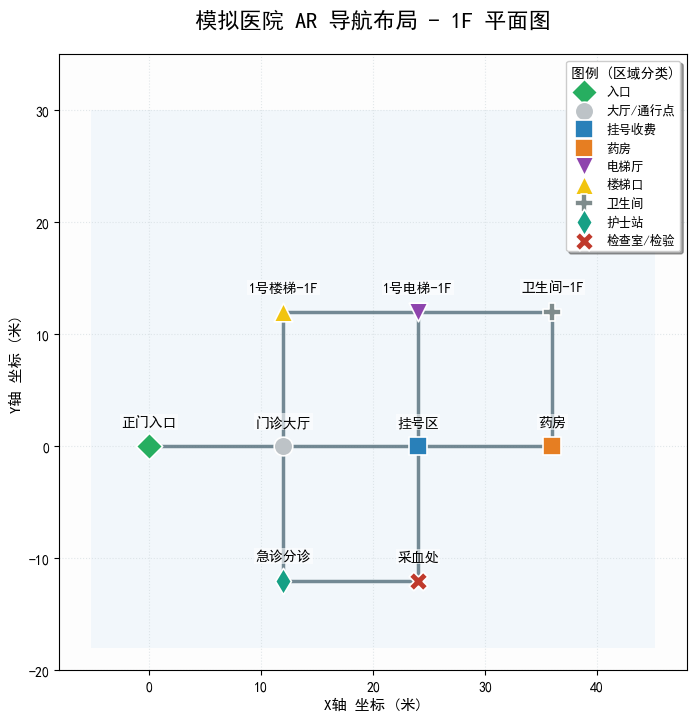

已成功保存: Hospital_Layout_Floor_2.png (DPI=300)


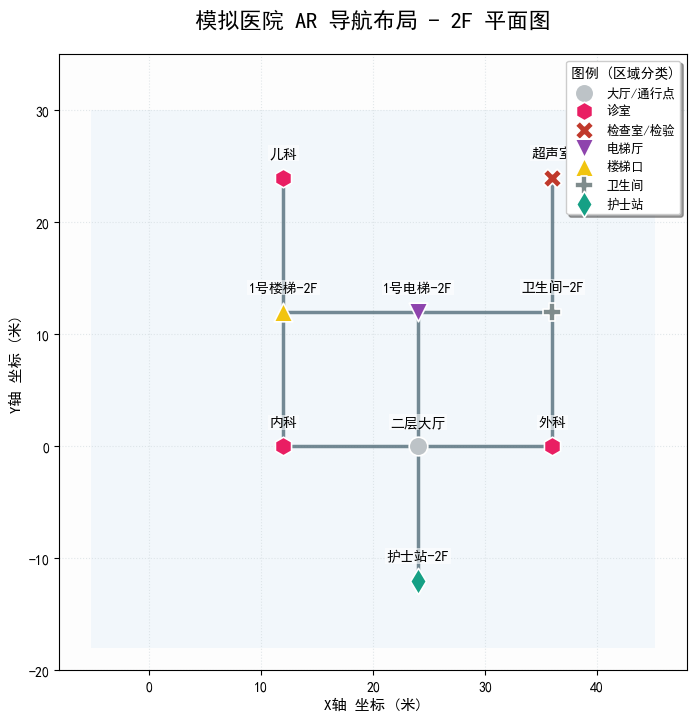

已成功保存: Hospital_Layout_Floor_3.png (DPI=300)


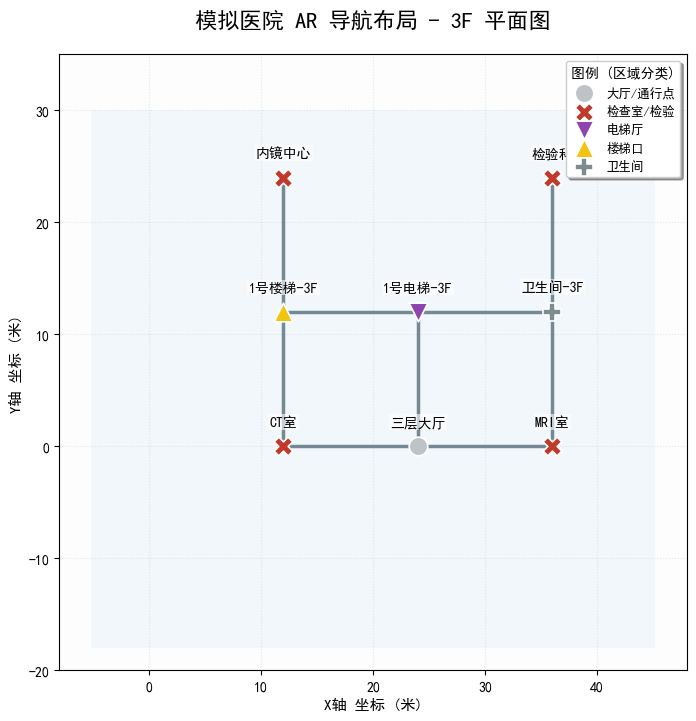

In [4]:
import matplotlib.pyplot as plt
import matplotlib

# --- 1. 环境配置 (支持中文与导出质量) ---
matplotlib.rc('font', family='SimHei') 
matplotlib.rcParams['axes.unicode_minus'] = False 

# --- 2. 样式与数据定义 ---
type_map_zh = {
    'ENTRANCE': '入口', 'REGISTRATION': '挂号收费', 'PHARMACY': '药房',
    'ELEVATOR': '电梯厅', 'STAIRS': '楼梯口', 'CLINIC': '诊室',
    'EXAMINATION': '检查室/检验', 'NURSE_STATION': '护士站',
    'RESTROOM': '卫生间', 'NORMAL': '大厅/通行点'
}

type_styles = {
    'ENTRANCE': ('#27ae60', 'D'), 'REGISTRATION': ('#2980b9', 's'),
    'PHARMACY': ('#e67e22', 's'), 'ELEVATOR': ('#8e44ad', 'v'),
    'STAIRS': ('#f1c40f', '^'), 'CLINIC': ('#e91e63', 'h'),
    'EXAMINATION': ('#c0392b', 'X'), 'NURSE_STATION': ('#16a085', 'd'),
    'RESTROOM': ('#7f8c8d', 'P'), 'NORMAL': ('#bdc3c7', 'o')
}

# 节点与边数据 (此处引用之前定义的 full_nodes 和 raw_edges)
# ... [请确保 full_nodes 和 raw_edges 在你的环境中已定义] ...

# --- 3. 循环生成并保存单张图 ---

def export_hospital_floor_plans(dpi_value=300):
    node_dict = {n[0]: n for n in full_nodes}
    
    for floor in [1, 2, 3]:
        # 创建独立画布
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111)
        
        # A. 视觉美化：绘制建筑底板感
        ax.set_facecolor('#fdfdfd')
        ax.axhspan(-18, 30, xmin=0.05, xmax=0.95, facecolor='#3498db', alpha=0.05)
        
        # B. 绘制本层路径
        for start_id, end_id in raw_edges:
            n1, n2 = node_dict[start_id], node_dict[end_id]
            if n1[2] == floor and n2[2] == floor:
                ax.plot([n1[3], n2[3]], [n1[4], n2[4]], color='#546e7a', lw=2.5, alpha=0.8, zorder=2)

        # C. 绘制本层节点
        plotted_for_legend = {}
        for _, name, f, x, y, n_type in full_nodes:
            if f == floor:
                color, mkr = type_styles.get(n_type, ('#95a5a6', 'o'))
                sc = ax.scatter(x, y, s=180, c=color, marker=mkr, edgecolors='white', lw=1.2, zorder=5)
                
                # 记录以便生成本图图例
                if n_type not in plotted_for_legend:
                    plotted_for_legend[n_type] = sc
                
                # 标注名称 (带微小偏移)
                ax.text(x, y + 1.8, name, fontsize=10, ha='center', weight='bold', 
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

        # D. 图表装饰
        ax.set_title(f"模拟医院 AR 导航布局 - {floor}F 平面图", fontsize=16, pad=20, weight='bold')
        ax.set_xlabel("X轴 坐标 (米)", fontsize=11)
        ax.set_ylabel("Y轴 坐标 (米)", fontsize=11)
        ax.set_xlim(-8, 48)
        ax.set_ylim(-20, 35)
        ax.grid(True, linestyle=':', color='#cfd8dc', alpha=0.6)
        ax.set_aspect('equal')

        # E. 生成本图专属中文图例
        handles = [plotted_for_legend[t] for t in plotted_for_legend]
        labels = [type_map_zh[t] for t in plotted_for_legend]
        ax.legend(handles, labels, title="图例 (区域分类)", loc='upper right', fontsize=9, shadow=True)

        # F. 保存图片
        file_name = f"Hospital_Layout_Floor_{floor}.png"
        plt.savefig(file_name, dpi=dpi_value, bbox_inches='tight')
        print(f"已成功保存: {file_name} (DPI={dpi_value})")
        
        # 展示
        plt.show()

# 执行导出
export_hospital_floor_plans(dpi_value=300)